# Imports

In [75]:
import matplotlib.pyplot as plt
import numpy as np
import sys
from scipy.integrate import cumulative_trapezoid
from scipy import constants
from urllib.request  import urlopen #python 3.0 
from urllib.request  import urlretrieve #python 3.0 
import urllib
import os
from enum import Enum

# The following line activates the inline plotting backend in the notebook.
%matplotlib inline

### Utility functions

In [76]:
def print_warning(message):
    print('\033[91m' + message + '\033[0m')

# Setup

### Constants

In [77]:
V_p = 0.057 #m^3 Plasma volume
k_B = constants.k # Boltzmann constant
eV = constants.e # 1 eV equivalent to J

ShotNo = 48251

In [78]:
class Parameter(Enum):
    U_loop = ('Diagnostics/BasicDiagnostics/Results/U_loop', 1)
    I_p = ('Diagnostics/BasicDiagnostics/Results/Ip', 1e3)
    I_ch = ('Diagnostics/BasicDiagnostics/Results/Ich', 1e3)
    n_e_lav = ('Diagnostics/Interferometry/Results/ne_lav')

    def __init__(self, path, conversion_factor=1):
        self.path = path
        self.conversion_factor = conversion_factor

### Data acquisition functions

In [79]:
baseURL = "http://golem.fjfi.cvut.cz/shots/"

try:
        os.stat('shots/')
except:
        os.mkdir('shots/') 

def open_data(shot_no, paremeter:Parameter):
    data_path = paremeter.path
    shotDIR = 'shots/' + str(shot_no)
    dataADR = shotDIR + '/' + str(paremeter.name) + '.csv' # where we put it
    dataURL = baseURL + str(shot_no) + '/' + data_path + '.csv' # where we get it
    
    try:
        os.stat(shotDIR)
        # print('Directory ' + shotDIR + ' already exists.')
    except:
        os.mkdir(shotDIR) 

    try:
        data = np.genfromtxt(dataADR, delimiter=',', skip_header=1)
    except:    
        download_data(dataURL, dataADR)
        data = np.genfromtxt(dataADR, delimiter=',', skip_header=1)

    return data 

def download_data(URL, download_to_path):
        print('Downloading data from ' + URL + ' into ' + download_to_path)
        a = urlretrieve(URL, download_to_path)
        print(a)

In [80]:
def GetParameterDataFromShot(shot_no, parameter:Parameter):
    data = open_data(shot_no, parameter)
    return data[:,0], data[:,1]*parameter.conversion_factor # time, data

In [81]:
def InterpolateDataToTimeArray(time, data, new_time):
    return np.interp(new_time, time, data)

# Data acquisition

In [82]:
times = {}
datas = {}

for i, paremeter in enumerate(Parameter):
    time, data = GetParameterDataFromShot(ShotNo, paremeter)
    times[paremeter] = time
    datas[paremeter] = data


### Handle time array

In [83]:
# Test that time arrays are sorted
for paremeter, time in times.items():
    if not np.all(np.diff(time) > 0):
        # Warning in red
        print_warning('Time array for ' + str(paremeter) + ' is not sorted!')

In [84]:
# Make sure everything has the same time scale

# First find minimum and maxmium time across all data
min_time = min([time[0] for time in times.values()])
max_time = max([time[-1] for time in times.values()])

time_baseline = Parameter.U_loop

for i, parameterID in enumerate(Parameter):
    # discard data outside of the common time range
    if times[parameterID][0] < min_time or times[parameterID][-1] > max_time:
        common_time_range_mask = (times[parameterID] >= min_time) & (times[parameterID] <= max_time)
        times[parameterID] = times[parameterID][common_time_range_mask]
        datas[parameterID] = datas[parameterID][common_time_range_mask]

    # interpolate to the time baseline if not already on it
    if times[parameterID] is not times[time_baseline]:
        datas[parameterID] = InterpolateDataToTimeArray(times[parameterID], datas[parameterID], times[time_baseline])
        times[parameterID] = times[time_baseline]


# Check that all time arrays are now the same
for paremeter, time in times.items():
    if not np.array_equal(time, times[time_baseline]):
        print_warning('Time array for ' + str(paremeter) + ' is not the same as the baseline time array!')

time = times[time_baseline]

### Put data into named variables

In [85]:
U_loop = datas[Parameter.U_loop]
I_p = datas[Parameter.I_p]
n_e_lav = datas[Parameter.n_e_lav]

### Plot obtained data

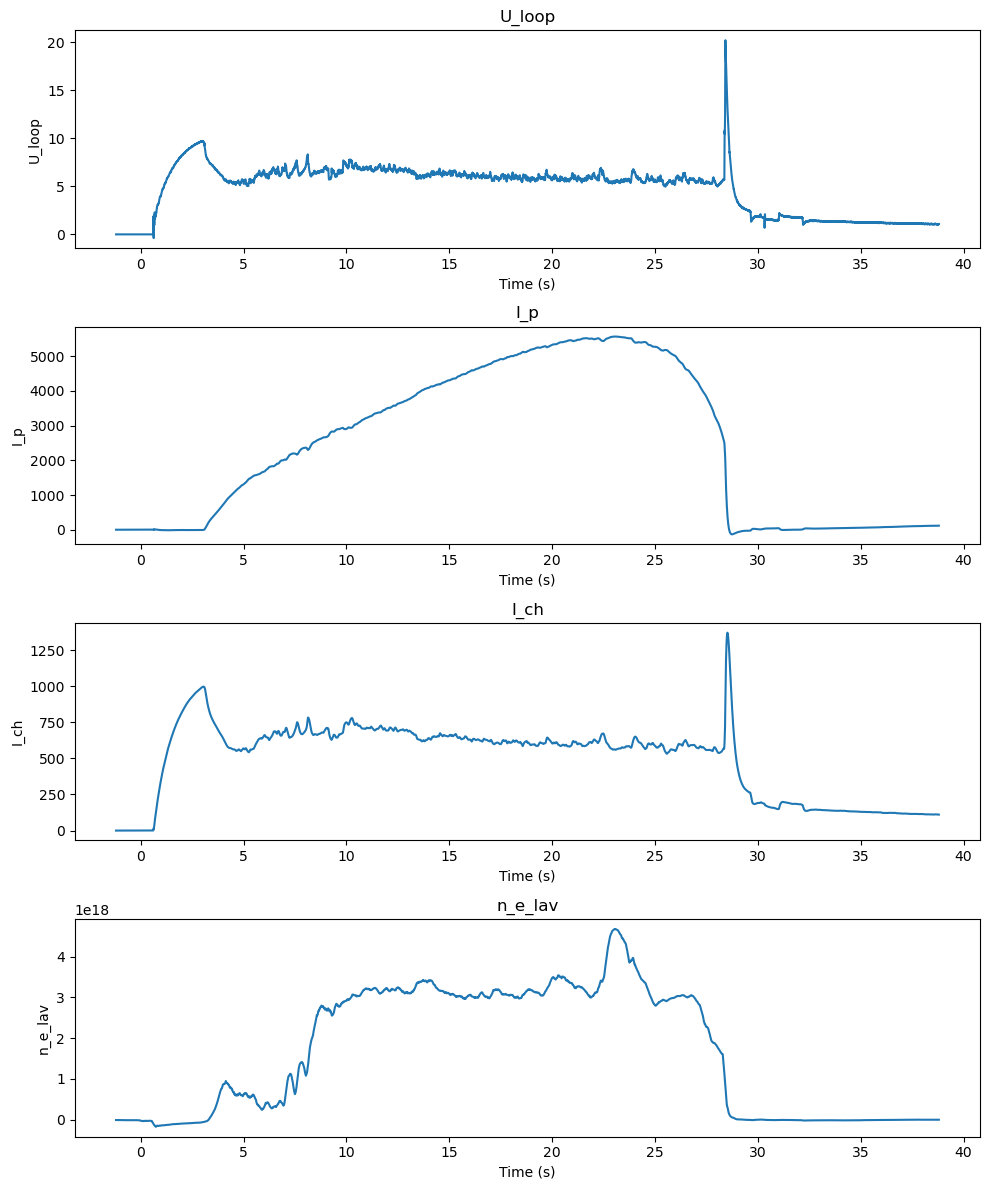

In [86]:
fig, axs = plt.subplots(len(Parameter), 1, figsize=(10, 3*len(Parameter)))
for i, paremeter in enumerate(Parameter):
    time, data = times[paremeter], datas[paremeter]
    axs[i].plot(time, data)
    axs[i].set_title(str(paremeter.name))
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel(str(paremeter.name))
plt.tight_layout()
plt.show()

# Data Processing

In [87]:
R_p = np.maximum(0,U_loop/I_p) # plasma resistivity adopted to avoid power(xx,-2./3) problems @ T_e calculation
P_OH = U_loop*I_p  # Plasma heating power
T_e_eV = 0.9*R_p**(-2./3) # Electron temperature (the GOLEM specific case)
W_p = V_p*n_e_lav*eV*T_e_eV/3 # Energy content in the plasma

tau = W_p/P_OH 

C:\Users\20223667\AppData\Local\Temp\ipykernel_29136\1095017863.py:1: RuntimeWarning: invalid value encountered in divide
  R_p = np.maximum(0,U_loop/I_p) # plasma resistivity adopted to avoid power(xx,-2./3) problems @ T_e calculation
C:\Users\20223667\AppData\Local\Temp\ipykernel_29136\1095017863.py:3: RuntimeWarning: divide by zero encountered in power
  T_e_eV = 0.9*R_p**(-2./3) # Electron temperature (the GOLEM specific case)


### Plot result

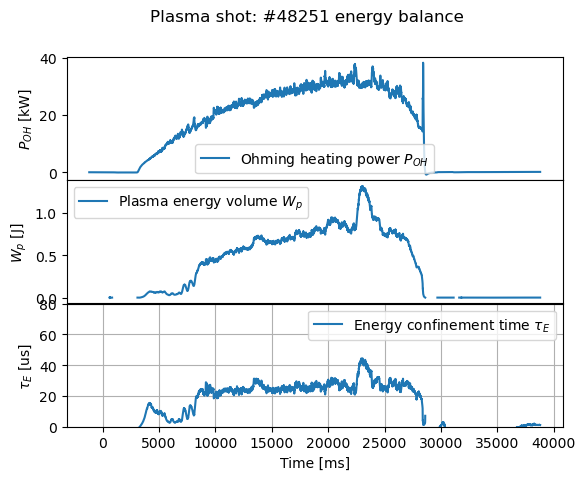

Energy confinement time =  (nan +/- nan) us


c:\Users\20223667\.conda\envs\sci-prog\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
c:\Users\20223667\.conda\envs\sci-prog\Lib\site-packages\numpy\_core\_methods.py:170: RuntimeWarning: invalid value encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)


In [88]:
f,ax = plt.subplots(3, sharex=True)
f.suptitle('Plasma shot: #'+str(ShotNo)+ ' energy balance')

f.subplots_adjust(hspace=0.001)
ax[0].set_ylabel('$P_{OH}$ [kW]')
ax[0].plot(time*1e3, P_OH/1000,label='Ohming heating power $P_{OH}$')
ax[1].set_ylabel('$W_p$ [J]')
ax[1].plot(time*1e3,W_p,label='Plasma energy volume $W_p$')
ax[2].set_ylabel(r'$\tau_E$ [us]')
ax[2].plot(time*1e3,tau*1e6,label=r'Energy confinement time $\tau_E$')
ax[2].set_ylim(0,80)
ax[2].grid('on')
[a.legend(loc='best') for a in ax]
ax[-1].set_xlabel('Time [ms]')
plt.show()

# Final calculation
tau_mean, tau_mean_err = np.mean(tau), np.std(tau)
print("Energy confinement time =  (%.0f +/- %.0f) us"%(tau_mean*1e6,tau_mean_err*1e6))

# Triple Product

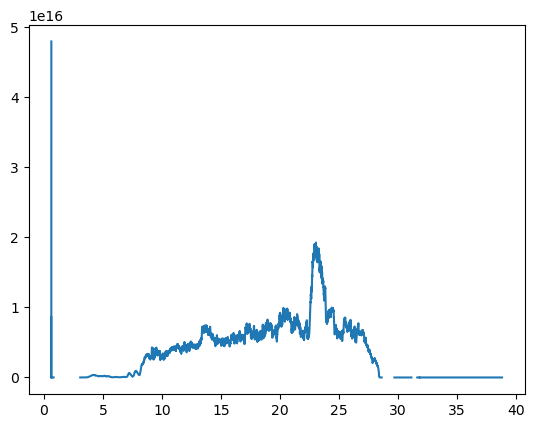

In [89]:
nTtau = n_e_lav*T_e_eV*tau
plt.plot(time, nTtau)


### Calculating the mean

We find the start and end time of the plasma based on the ohmic heating. We set the first time the heating power passes some relative threshold as the starting time, and the last time it does so as the end time.

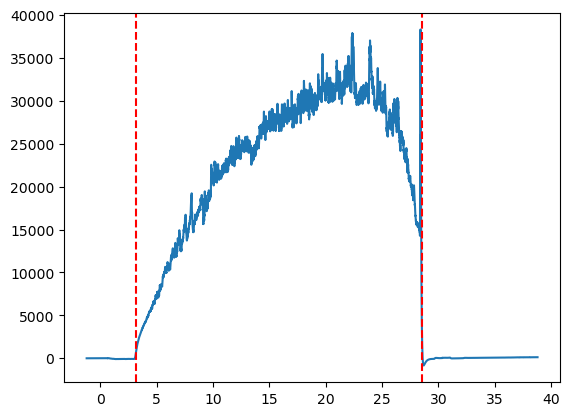

In [90]:
cutoff_relative_strength = 0.01 # 1% of the maximum value
start_idx = np.where(P_OH > P_OH.max() * cutoff_relative_strength)[0][0]
t_start = time[start_idx] # start time of the plasma, defined as when the ohmic power exceeds 10% of its maximum value
end_idx = np.where(P_OH > P_OH.max() * cutoff_relative_strength)[0][-1]
t_end = time[end_idx] # end time of the plasma, defined as when the ohmic power exceeds 10% of its maximum value
plt.plot(time, P_OH)
plt.axvline(t_start, color='r', linestyle='--', label='Start time')
plt.axvline(t_end, color='r', linestyle='--', label='End time')

nTtau = 5.00e+15 m^-3 eV s
max_nTtau = 1.92e+16 m^-3 eV s


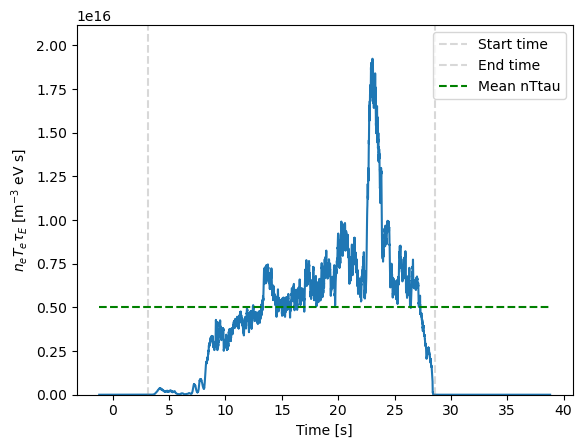

In [95]:
trimmed_nTtau = np.zeros_like(nTtau)
trimmed_nTtau[start_idx:end_idx] = nTtau[start_idx:end_idx]

mean_nTtau = trimmed_nTtau[trimmed_nTtau > 0].mean()
max_nTtau = trimmed_nTtau[trimmed_nTtau > 0].max()
print("nTtau = %.2e m^-3 eV s"%(mean_nTtau))
print("max_nTtau = %.2e m^-3 eV s"%(max_nTtau))

fig, ax = plt.subplots()
ax.plot(time, trimmed_nTtau)
ax.axvline(t_start, color='gray', alpha = 0.3, linestyle='--', label='Start time')
ax.axvline(t_end, color='gray', alpha = 0.3, linestyle='--', label='End time')
ax.set_ylim(0, max_nTtau*1.1)
ax.set_xlabel('Time [s]')
ax.set_ylabel(r'$n_e T_e \tau_E$ [m$^{-3}$ eV s]')
ax.hlines(mean_nTtau, time[0], time[-1], color='g', linestyle='--', label='Mean nTtau')
ax.legend()